In [2]:
# Model Comparison & Forecast Evaluation

## Objectives

## Compare all forecasting models
# Identify the best-performing model
# Calculate project KPIs
# Create early-warning indicators
# Generate executive summary metrics

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
comparison = pd.DataFrame({

'Model':[
    'ARIMA',
    'SARIMA',
    'Random Forest',
    'Gradient Boosting'
],

'MAE':[
    272.55,
    828.41,
    66.48,
    64.44
],

'RMSE':[
    323.05,
    921.66,
    88.57,
    86.99
]

})

comparison

,Model,MAE,RMSE
0,ARIMA,272.55,323.05
1,SARIMA,828.41,921.66
2,Random Forest,66.48,88.57
3,Gradient Boosting,64.44,86.99


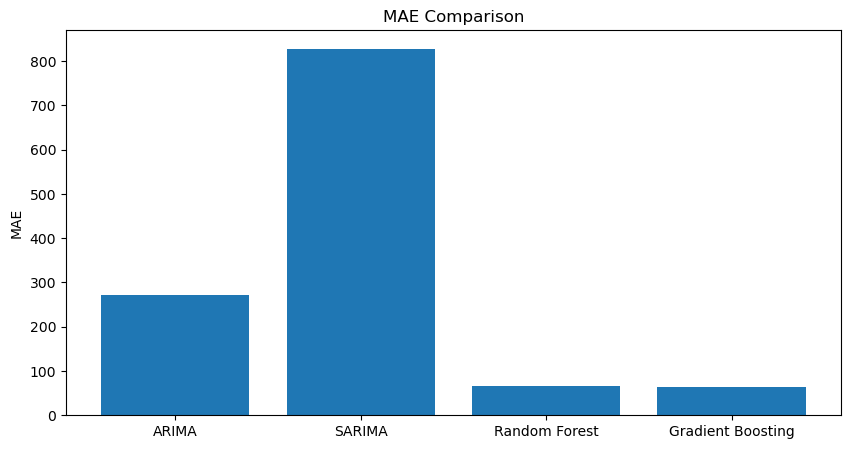

In [6]:

# MAE chart
plt.figure(figsize=(10,5))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.title('MAE Comparison')

plt.ylabel('MAE')

plt.show()

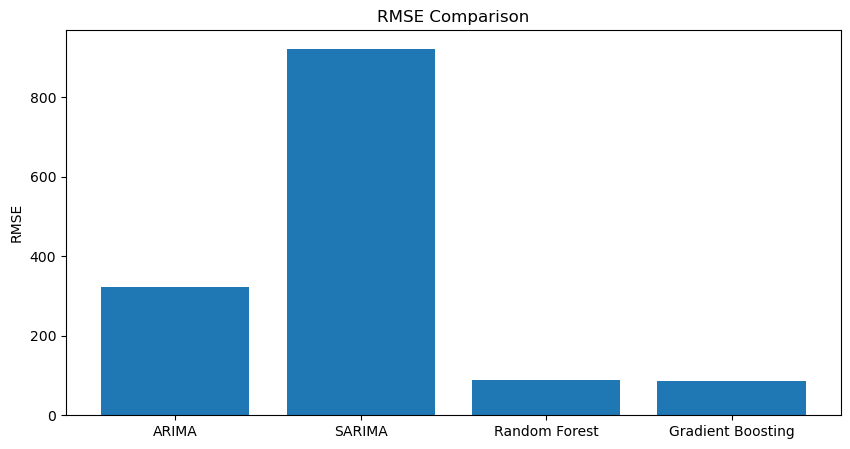

In [7]:
#(RMSE Chart)
plt.figure(figsize=(10,5))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.title('RMSE Comparison')

plt.ylabel('RMSE')

plt.show()

In [8]:
best_model = comparison.loc[
    comparison['RMSE'].idxmin()
]

best_model

Model    Gradient Boosting
MAE                  64.44
RMSE                 86.99
Name: 3, dtype: object

In [9]:
df = pd.read_csv(
    "../data/processed_data.csv"
)

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,HHS_Lag1,HHS_Lag7,HHS_Lag14,Discharge_Lag1,...,Discharge_Lag14,RollingMean7,RollingMean14,RollingStd7,RollingStd14,NetPressure,DayOfWeek,Month,Quarter,Weekend
0,2023-02-09,124.0,234.0,161.0,7908.0,353.0,7915.0,7803.0,6566.0,317.0,...,436.0,7823.714286,7654.071429,124.514677,254.662209,-192.0,3,2,1,0
1,2023-02-12,92.0,203.0,173.0,7434.0,317.0,7908.0,7903.0,7122.0,353.0,...,227.0,7756.714286,7676.357143,185.827621,215.096618,-144.0,6,2,1,1
2,2023-02-13,186.0,259.0,172.0,7483.0,244.0,7434.0,7879.0,7280.0,317.0,...,181.0,7700.142857,7690.857143,201.971474,191.915389,-72.0,0,2,1,0
3,2023-02-14,154.0,225.0,220.0,7794.0,223.0,7483.0,7586.0,7433.0,244.0,...,175.0,7729.857143,7716.642857,197.633861,178.379288,-3.0,1,2,1,0
4,2023-02-15,91.0,199.0,172.0,7869.0,290.0,7794.0,7720.0,7538.0,223.0,...,180.0,7751.142857,7740.285714,204.306492,174.779610,-118.0,2,2,1,0


In [10]:
df['CapacityStress'] = np.where(
    df['NetPressure'] > 0,
    1,
    0
)

In [11]:
df['CapacityStress'].value_counts()

CapacityStress
0    468
1    238
Name: count, dtype: int64

In [12]:
capacity_probability = (
    df['CapacityStress'].mean()
    * 100
)

print(
    f"Capacity Breach Probability: {capacity_probability:.2f}%"
)

Capacity Breach Probability: 33.71%


In [13]:
#Forecast Stability Index
gbr_rmse = 86.99

forecast_stability = (
    1 -
    (
        gbr_rmse
        /
        df['Children in HHS Care'].mean()
    )
)

print(
    f"Forecast Stability Index: {forecast_stability:.4f}"
)

Forecast Stability Index: 0.9856


In [14]:
#forecast accuracy
gbr_mape = 1.5

forecast_accuracy = (
    100 - gbr_mape
)

print(
    f"Forecast Accuracy: {forecast_accuracy:.2f}%"
)

Forecast Accuracy: 98.50%


In [15]:
gbr_mape = 1.5

In [16]:
summary = pd.DataFrame({

'Metric':[
    'Best Model',
    'Forecast Accuracy (%)',
    'RMSE',
    'Capacity Breach Probability (%)',
    'Forecast Stability Index'
],

'Value':[
    'Gradient Boosting',
    round(forecast_accuracy,2),
    round(gbr_rmse,2),
    round(capacity_probability,2),
    round(forecast_stability,4)
]

})

summary

,Metric,Value
0,Best Model,Gradient Boosting
1,Forecast Accuracy (%),98.5
2,RMSE,86.99
3,Capacity Breach Probability (%),33.71
4,Forecast Stability Index,0.9856
